In [1]:
import sys
sys.path.append(r'C:\Users\Lenovo\Desktop\2025 ICM\2025_E\tools/')
from IM_dataset import IM_dataset
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator

In [2]:
IM_data = IM_dataset(1000)

In [3]:
batch_size = 16
data_loader = LoadArray(IM_data,batch_size)

In [4]:
model = gluon.nn.Sequential()
model.add(

    # gluon.nn.Dense(64, activation='relu'),
    gluon.nn.Dense(64),
    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))

In [5]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'adam',{'learning_rate':0.0001})

In [6]:
best_loss = float(100)

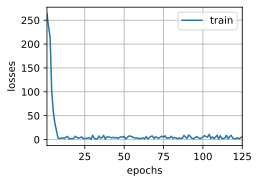

In [7]:
epochs = 125
animator = Animator(xlabel='epochs',ylabel='losses',legend=['train'],xlim=[1,epochs])
for epoch in range(epochs):
    epoch_loss = 0
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
                # print(feature,model(feature))
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
            epoch_loss += temp
    animator.add(epoch+1, (temp,))

In [8]:
from mxnet import np, npx
npx.set_np()
feature = np.array([[2.08,	112.32,	1.89

]])
model(feature)

array([[26.190048]])